# One-at-a-Time (OAT) Manning's n Sensitivity Analysis

This notebook performs a **one-at-a-time (OAT)** sensitivity analysis on Manning's n values
using a 2D HEC-RAS model. Each land cover class is varied individually while holding all
others at their baseline values, producing sensitivity curves and tornado diagrams that
show which land cover classes most affect water surface elevation.

**Key concepts:**
- OAT sensitivity: vary one parameter at a time to isolate its effect
- Manning's n range tables with configurable interval stepping
- Per-plan cloned geometries with plaintext `LCMann Table` edits through `GeomLandCover`
- Geometry-preprocessor refresh with `clear_geompre=True` so cached cell n values update
- Post-run verification that preprocessed 2D cell Manning's n values actually changed
- Parallel plan execution with local `RasCmdr.compute_parallel()` by default
- Optional RasRemote execution when a worker JSON is supplied explicitly
- Baseline-anchored sensitivity curves and tornado diagram visualization

**Prerequisites:** HEC-RAS 7.0+ installed, ras-commander package


In [1]:
from pathlib import Path
import os
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from ras_commander import (
        init_ras_project, RasCmdr, RasPlan, RasExamples,
        RasMap, RasCurrency
    )
    from ras_commander.geom import GeomLandCover
    from ras_commander.hdf import HdfLandCover, HdfMesh, HdfResultsMesh
except ImportError:
    current_file = Path("__file__").resolve()
    parent_directory = current_file.parent.parent
    sys.path.append(str(parent_directory))
    from ras_commander import (
        init_ras_project, RasCmdr, RasPlan, RasExamples,
        RasMap, RasCurrency
    )
    from ras_commander.geom import GeomLandCover
    from ras_commander.hdf import HdfLandCover, HdfMesh, HdfResultsMesh


## Configuration

All parameters for the analysis are defined here. Adjust `INTERVAL` to control
the granularity of the sensitivity sweep (smaller interval = more plans = longer runtime).

In [2]:
# === PROJECT CONFIGURATION ===
PROJECT_NAME = os.getenv("RAS_COMMANDER_711_PROJECT_NAME", "Muncie")
PROJECT_PATH_OVERRIDE = os.getenv("RAS_COMMANDER_711_PROJECT_PATH")
RAS_VERSION = os.getenv("RAS_COMMANDER_711_RAS_VERSION", "7.0")
TEMPLATE_PLAN = os.getenv("RAS_COMMANDER_711_TEMPLATE_PLAN", "04")

# === SENSITIVITY CONFIGURATION ===
INTERVAL = float(os.getenv("RAS_COMMANDER_711_INTERVAL", "0.02"))
OBSTRUCTION_THRESHOLD = 1.0  # n values >= this are obstructions

# === POINT OF INTEREST ===
# Location in model coordinates (State Plane Indiana East, ft)
# Selected at ~p50 of max WSE across all mesh cells in the Muncie example.
POI_X = float(os.getenv("RAS_COMMANDER_711_POI_X", "408350.0"))
POI_Y = float(os.getenv("RAS_COMMANDER_711_POI_Y", "1802550.0"))
POI_LABEL = os.getenv("RAS_COMMANDER_711_POI_LABEL", "Mid-Floodplain POI")

# === EXECUTION ===
RUN_HECRAS = os.getenv("RAS_COMMANDER_711_RUN_HECRAS", "1").lower() in {"1", "true", "yes"}
MAX_WORKERS = int(os.getenv("RAS_COMMANDER_711_MAX_WORKERS", "4"))
NUM_CORES = int(os.getenv("RAS_COMMANDER_711_NUM_CORES", "2"))
CLEAR_GEOMPRE = os.getenv("RAS_COMMANDER_711_CLEAR_GEOMPRE", "1").lower() in {"1", "true", "yes"}
FORCE_RERUN = os.getenv("RAS_COMMANDER_711_FORCE_RERUN", "1").lower() in {"1", "true", "yes"}

# Remote execution is opt-in and requires a user-supplied worker JSON.
USE_REMOTE_WORKERS = os.getenv("RAS_COMMANDER_711_USE_REMOTE_WORKERS", "0").lower() in {"1", "true", "yes"}
REMOTE_WORKERS_JSON = os.getenv("RAS_COMMANDER_711_REMOTE_WORKERS_JSON")

# Optional RASMapper layer selectors. Leave blank to auto-select registered layers.
TERRAIN_LAYER_NAME = os.getenv("RAS_COMMANDER_711_TERRAIN_LAYER", "")
LANDCOVER_LAYER_NAME = os.getenv("RAS_COMMANDER_711_LANDCOVER_LAYER", "")


## Extract Example Project and Initialize

In [3]:
if PROJECT_PATH_OVERRIDE:
    project_folder = Path(PROJECT_PATH_OVERRIDE).expanduser()
    project_source = "external override"
else:
    project_folder = RasExamples.extract_project(PROJECT_NAME)
    project_source = "RasExamples"

ras = init_ras_project(project_folder, RAS_VERSION, hide_intro=True)

display_project_folder = Path(project_folder)
try:
    display_project_folder = display_project_folder.relative_to(Path.cwd())
except ValueError:
    display_project_folder = display_project_folder.name
print(f"Project: {display_project_folder}")
print(f"Source: {project_source}")
print(f"RAS version: {RAS_VERSION}")
print(f"Plans: {len(ras.plan_df)}")
print(f"Template plan: {TEMPLATE_PLAN}")
print("\nPlan DataFrame:")
ras.plan_df[["plan_number", "Plan Title", "Geom File"]].head(10)


2026-07-08 05:41:35 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to example_projects\Muncie


Project: example_projects\Muncie
Source: RasExamples
RAS version: 7.0
Plans: 3
Template plan: 04

Plan DataFrame:


,plan_number,Plan Title,Geom File
0,01,Unsteady Multi 9-SA run,01
1,03,Unsteady Run with 2D 50ft Grid,02
2,04,Unsteady Run with 2D 50ft User n Value R,04


## Read Baseline Manning’s n Values

Extract the current Manning’s n values from the template geometry file.
These serve as the baseline for the OAT sensitivity analysis.

In [4]:
# Resolve the template geometry from the ras-commander plan DataFrame.
plan_numbers = ras.plan_df["plan_number"].astype(str).str.zfill(2)
template_matches = ras.plan_df[plan_numbers == str(TEMPLATE_PLAN).zfill(2)]
if template_matches.empty:
    raise ValueError(f"Template plan {TEMPLATE_PLAN} was not found in ras.plan_df")

template_row = template_matches.iloc[0]
if "geometry_number" in template_row and pd.notna(template_row["geometry_number"]):
    template_geom_number = str(template_row["geometry_number"]).zfill(2)
else:
    geom_token = str(template_row.get("Geom File", template_row.get("Geom Path", "")))
    template_geom_number = geom_token.rsplit(".g", 1)[-1].split(".")[0].zfill(2)

geom_candidate = template_row.get("Geom Path", template_row.get("Geom File"))
geom_file = Path(geom_candidate)
if not geom_file.is_absolute():
    geom_file = ras.project_folder / geom_file
if not geom_file.exists():
    geom_file = ras.project_folder / f"{ras.project_name}.g{template_geom_number}"
if not geom_file.exists():
    raise FileNotFoundError(f"Could not resolve template geometry file for plan {TEMPLATE_PLAN}")

# Read base overrides (primary Manning's n table) from the plaintext geometry.
base_overrides_df = GeomLandCover.get_base_mannings_n(geom_file).copy()
if base_overrides_df.empty:
    raise ValueError(f"No base Manning's n table found in {geom_file.name}")

base_overrides_df["Base Mannings n Value"] = pd.to_numeric(
    base_overrides_df["Base Mannings n Value"], errors="coerce"
)
base_overrides = dict(zip(
    base_overrides_df["Land Cover Name"],
    base_overrides_df["Base Mannings n Value"],
))

print("Base Manning's n Overrides:")
print(f"  Geometry: {geom_file.name}")
print(f"  Land covers: {len(base_overrides)}")
for name, n_val in base_overrides.items():
    print(f"  {name}: n = {n_val}")

# Read regional overrides, if present.
regional_overrides_df = GeomLandCover.get_region_mannings_n(geom_file)
print(f"\nRegional Overrides: {len(regional_overrides_df)} rows")
regional_overrides_df.head(10)


Base Manning's n Overrides:
  Geometry: Muncie.g04
  Land covers: 6
  building: n = 100.0
  medium density residential: n = 0.08
  open space: n = 0.04
  park: n = 0.06
  trees: n = 0.12
  urban: n = 0.1

Regional Overrides: 6 rows


,Table Number,Land Cover Name,MainChannel,Region Name
0,6,building,100.000,Flat Area
1,6,medium density residential,0.072,Flat Area
2,6,open space,0.036,Flat Area
3,6,park,0.054,Flat Area
4,6,trees,0.108,Flat Area
5,6,urban,0.090,Flat Area


## Model Context

Summarize the template plan, simulation settings, and boundary-condition table before creating sensitivity variants. The summary uses ras-commander DataFrames and omits full paths so the published notebook stays concise.


In [5]:
context_cols = [
    "plan_number", "Plan Title", "Program Version", "Geom File", "Flow File",
    "Unsteady File", "flow_type", "Simulation Date", "Computation Interval",
    "Output Interval", "Mapping Interval", "geometry_number", "unsteady_number",
]
available_context_cols = [col for col in context_cols if col in template_row.index]
template_context_df = template_row[available_context_cols].to_frame(name="value")
template_context_df.index.name = "template_plan_field"
print("Template plan context:")
display(template_context_df)

boundary_df = getattr(ras, "boundaries_df", pd.DataFrame())
if boundary_df is None or boundary_df.empty:
    print("Boundary condition rows: 0")
else:
    boundary_df = boundary_df.copy()
    print(f"Boundary condition rows: {len(boundary_df)}")

    type_col = next((col for col in boundary_df.columns if "type" in str(col).lower()), None)
    if type_col:
        boundary_counts_df = (
            boundary_df[type_col]
            .fillna("unspecified")
            .astype(str)
            .value_counts()
            .rename_axis("boundary_type")
            .reset_index(name="count")
        )
        display(boundary_counts_df)

    preferred_boundary_cols = [
        "boundary_type", "Boundary Type", "type", "bc_type", "name", "boundary_name",
        "location", "river", "River", "reach", "Reach", "station", "rs", "RS",
        "geometry_number", "unsteady_number", "plan_number",
    ]
    boundary_cols = [col for col in preferred_boundary_cols if col in boundary_df.columns]
    if not boundary_cols:
        boundary_cols = [
            col for col in boundary_df.columns
            if not any(token in str(col).lower() for token in ("path", "file", "full"))
        ][:8]

    if boundary_cols:
        display(boundary_df[boundary_cols].head(12))
    else:
        print("Boundary condition columns are path/file fields only; no concise table displayed.")


Template plan context:


,value
template_plan_field,
plan_number,04
Plan Title,Unsteady Run with 2D 50ft User n Value R
Program Version,5.10
Geom File,04
Flow File,01
flow_type,Unsteady
Simulation Date,"02JAN1900,0000,02JAN1900,2400"
Computation Interval,10SEC
Mapping Interval,5MIN


Boundary condition rows: 2


,boundary_type,count
0,Flow Hydrograph,1
1,Normal Depth,1


,bc_type,unsteady_number
0,Flow Hydrograph,01
1,Normal Depth,01


## Mesh and POI Overview

Plot the template 2D mesh and point of interest before running the sensitivity sweep. This gives spatial context for the max-WSE extraction point used in the comparison plots.


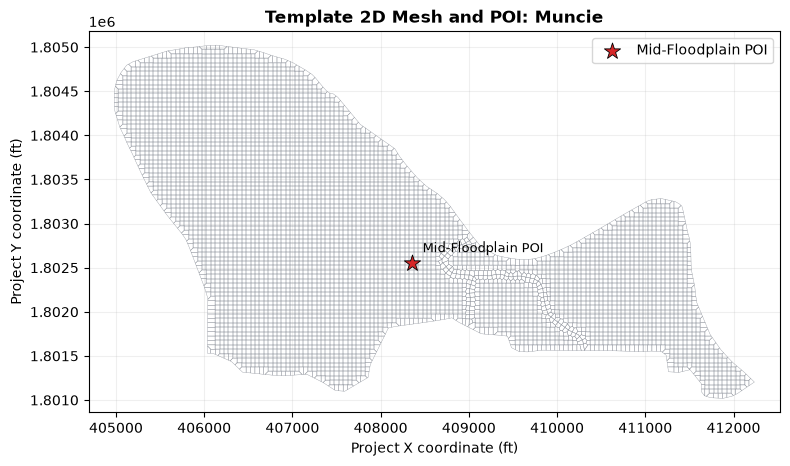

Mesh cells: 5,391 across 1 2D flow area(s)
Geometry HDF: Muncie.g04.hdf


In [6]:
template_geom_hdf = RasCurrency.get_geom_hdf_path(TEMPLATE_PLAN, ras)
if template_geom_hdf is None or not Path(template_geom_hdf).exists():
    raise FileNotFoundError(f"Could not resolve template geometry HDF for plan {TEMPLATE_PLAN}")

mesh_cells_gdf = HdfMesh.get_mesh_cell_polygons(template_geom_hdf)
if mesh_cells_gdf.empty:
    raise RuntimeError(f"No 2D mesh cell polygons were found in {template_geom_hdf.name}")

fig, ax = plt.subplots(figsize=(8, 7))
mesh_cells_gdf.boundary.plot(ax=ax, color="#8a8f98", linewidth=0.25)
ax.scatter(
    [POI_X], [POI_Y],
    marker="*", s=150, color="#d62728", edgecolor="black", linewidth=0.6,
    label=POI_LABEL, zorder=5,
)
ax.annotate(POI_LABEL, (POI_X, POI_Y), xytext=(8, 8), textcoords="offset points", fontsize=9)

xmin, ymin, xmax, ymax = mesh_cells_gdf.total_bounds
pad_x = max((xmax - xmin) * 0.04, 1.0)
pad_y = max((ymax - ymin) * 0.04, 1.0)
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Template 2D Mesh and POI: {ras.project_name}", fontweight="bold")
ax.set_xlabel("Project X coordinate (ft)")
ax.set_ylabel("Project Y coordinate (ft)")
ax.grid(True, alpha=0.2)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

mesh_area_count = mesh_cells_gdf["mesh_name"].nunique() if "mesh_name" in mesh_cells_gdf.columns else 1
print(f"Mesh cells: {len(mesh_cells_gdf):,} across {mesh_area_count} 2D flow area(s)")
print(f"Geometry HDF: {template_geom_hdf.name}")


## Build Manning’s n Range Table

Define the Manning's n sweep range for each land cover class. Common class names use literature-style ranges; project-specific names fall back to a conservative +/-50% range around the baseline value. Obstruction classes with very high n values are held constant.


In [7]:
# Standard Manning's n ranges by land cover type
# Source: HEC-RAS Reference Manual, Chow (1959)
MANNINGS_RANGES = {
    "Pasture":           (0.025, 0.050),
    "Brush":             (0.040, 0.120),
    "Trees":             (0.060, 0.200),
    "Low Intensity":     (0.040, 0.120),
    "High Intensity":    (0.060, 0.200),
    "Water":             (0.025, 0.050),
    "Cropland":          (0.020, 0.060),
    "Wetland":           (0.030, 0.100),
    "Barren":            (0.010, 0.035),
}

# Build range table from base overrides
range_table = {}
excluded = {}

for name, baseline_n in base_overrides.items():
    if pd.isna(baseline_n):
        excluded[name] = baseline_n
        continue
    if baseline_n >= OBSTRUCTION_THRESHOLD:
        excluded[name] = baseline_n
        continue
    
    if name in MANNINGS_RANGES:
        n_min, n_max = MANNINGS_RANGES[name]
    else:
        # Default: +/- 50% of baseline, clamped to [0.01, 0.5]
        n_min = max(0.01, baseline_n * 0.5)
        n_max = min(0.50, baseline_n * 1.5)
    
    steps = np.arange(n_min, n_max + INTERVAL / 2, INTERVAL)
    if not np.any(np.isclose(steps, baseline_n)):
        steps = np.sort(np.append(steps, baseline_n))

    range_table[name] = {
        "baseline": baseline_n,
        "min": n_min,
        "max": n_max,
        "steps": steps,
    }

print("=== Sensitivity Range Table ===")
print(f"Variable land covers: {len(range_table)}")
print(f"Excluded (obstructions or missing n): {len(excluded)}")
print()

total_plans = sum(len(v["steps"]) for v in range_table.values())
print(f"Total plans to create: {total_plans}")
print()

for name, info in range_table.items():
    print(f'  {name}: baseline={info["baseline"]:.3f}, '
          f'range=[{info["min"]:.3f}, {info["max"]:.3f}], '
          f'steps={len(info["steps"])}')

if excluded:
    print("\nExcluded:")
    for name, n_val in excluded.items():
        print(f"  {name}: n = {n_val}")


=== Sensitivity Range Table ===
Variable land covers: 5
Excluded (obstructions or missing n): 1

Total plans to create: 27

  medium density residential: baseline=0.080, range=[0.040, 0.120], steps=5
  open space: baseline=0.040, range=[0.020, 0.060], steps=3
  park: baseline=0.060, range=[0.030, 0.090], steps=5
  trees: baseline=0.120, range=[0.060, 0.180], steps=7
  urban: baseline=0.100, range=[0.050, 0.150], steps=7

Excluded:
  building: n = 100.0


## Create OAT Sensitivity Plans

For each land cover, create a set of plans that vary only that land cover’s
Manning’s n while keeping all others at baseline. Each plan gets a cloned
geometry file with modified Manning’s n values.

In [8]:
plan_registry = []  # Track all created plans
plan_counter = 0

for lc_name, info in range_table.items():
    print(f"\nCreating plans for: {lc_name} ({len(info['steps'])} steps)")
    
    for n_value in info["steps"]:
        plan_counter += 1
        safe_lc_name = "".join(ch for ch in str(lc_name) if ch.isalnum())[:10] or "LC"
        plan_title = f"OAT_{plan_counter:02d}_{safe_lc_name}_{float(n_value):.3f}"
        
        # Clone plan and geometry from the template.
        new_plan_number = RasPlan.clone_plan(TEMPLATE_PLAN, ras_object=ras)
        new_geom_number = RasPlan.clone_geom(template_geom_number, ras_object=ras)
        
        # Link cloned plan to cloned geometry and set a compact title.
        RasPlan.set_geom(new_plan_number, new_geom_number, ras_object=ras)
        RasPlan.set_plan_title(new_plan_number, plan_title, ras_object=ras)
        
        # Modify the cloned geometry's plaintext LCMann table directly with GeomLandCover.
        geom_path = ras.project_folder / f"{ras.project_name}.g{new_geom_number}"
        modified_mannings_df = base_overrides_df.copy()
        mask = modified_mannings_df["Land Cover Name"].astype(str) == str(lc_name)
        if not mask.any():
            raise ValueError(f"Land cover {lc_name!r} was not found in the base Manning's n table")
        modified_mannings_df.loc[mask, "Base Mannings n Value"] = float(n_value)
        if not GeomLandCover.set_base_mannings_n(geom_path, modified_mannings_df):
            raise RuntimeError(f"Failed to update Manning's n values in {geom_path.name}")
        
        plan_registry.append({
            "land_cover": lc_name,
            "n_value": round(float(n_value), 4),
            "baseline_n": float(info["baseline"]),
            "plan_number": str(new_plan_number).zfill(2),
            "geom_number": str(new_geom_number).zfill(2),
            "Plan Title": plan_title,
            "is_baseline": bool(np.isclose(float(n_value), float(info["baseline"])))
        })

# Refresh project state after creating plans/geometries.
ras = init_ras_project(project_folder, RAS_VERSION, hide_intro=True)

registry_df = pd.DataFrame(plan_registry)
print("\n=== Plan Registry ===")
print(f"Total plans created: {len(registry_df)}")
print(f"Land covers varied: {registry_df['land_cover'].nunique()}")
print("\nPlans per land cover:")
print(registry_df.groupby("land_cover").size())
registry_df.head(10)



Creating plans for: medium density residential (5 steps)



Creating plans for: open space (3 steps)



Creating plans for: park (5 steps)



Creating plans for: trees (7 steps)



Creating plans for: urban (7 steps)



=== Plan Registry ===
Total plans created: 27
Land covers varied: 5

Plans per land cover:
land_cover
medium density residential    5
open space                    3
park                          5
trees                         7
urban                         7
dtype: int64


,land_cover,n_value,baseline_n,plan_number,geom_number,Plan Title,is_baseline
0,medium density residential,0.04,0.08,02,03,OAT_01_mediumdens_0.040,False
1,medium density residential,0.06,0.08,05,05,OAT_02_mediumdens_0.060,False
2,medium density residential,0.08,0.08,06,06,OAT_03_mediumdens_0.080,True
3,medium density residential,0.10,0.08,07,07,OAT_04_mediumdens_0.100,False
4,medium density residential,0.12,0.08,08,08,OAT_05_mediumdens_0.120,False
5,open space,0.02,0.04,09,09,OAT_06_openspace_0.020,False
6,open space,0.04,0.04,10,10,OAT_07_openspace_0.040,True
7,open space,0.06,0.04,11,11,OAT_08_openspace_0.060,False
8,park,0.03,0.06,12,12,OAT_09_park_0.030,False
9,park,0.05,0.06,13,13,OAT_10_park_0.050,False


## Verify Cloned Geometry Associations

Each OAT plan uses a cloned geometry. The plaintext `.g##` stores the `LCMann Table`, but the compiled geometry HDF also needs terrain and land-cover associations so geometry preprocessing can sample per-cell Manning's n values. Some official example geometries do not store those attributes in the template HDF, so this notebook derives the sidecars from registered RASMapper layers and writes the association to each cloned geometry HDF.


In [9]:
def _normalize_class_name(value):
    return " ".join(str(value).strip().lower().split())


def _read_landcover_class_table(landcover_hdf_path):
    rows = []
    nodata_threshold = np.finfo(np.float32).max * 0.5
    with h5py.File(landcover_hdf_path, "r") as hdf_file:
        if all(name in hdf_file for name in ("IDs", "Names", "ManningsN")):
            ids = hdf_file["IDs"][()]
            names = hdf_file["Names"][()]
            mannings = hdf_file["ManningsN"][()]
            for pixel_value, raw_name, n_value in zip(ids, names, mannings):
                class_name = raw_name.decode("utf-8", errors="ignore").strip() if isinstance(raw_name, bytes) else str(raw_name).strip()
                n_value = float(n_value)
                if class_name.lower() == "nodata" or not np.isfinite(n_value) or n_value >= nodata_threshold:
                    continue
                rows.append({
                    "pixel_value": int(pixel_value),
                    "class_name": class_name,
                    "mannings_n": n_value,
                })
        else:
            variables_path = "Variables" if "Variables" in hdf_file else None
            if variables_path is None:
                return pd.DataFrame(columns=["pixel_value", "class_name", "mannings_n"])
            variables = hdf_file[variables_path][()]
            for pixel_value, row in enumerate(variables):
                class_name = row["Name"].decode("utf-8", errors="ignore").strip() if isinstance(row["Name"], bytes) else str(row["Name"]).strip()
                n_value = float(row["ManningsN"]) if "ManningsN" in variables.dtype.names else np.nan
                if class_name.lower() == "nodata" or not np.isfinite(n_value) or n_value >= nodata_threshold:
                    continue
                rows.append({
                    "pixel_value": int(pixel_value),
                    "class_name": class_name,
                    "mannings_n": n_value,
                })
    return pd.DataFrame(rows)


def _select_named_layer(layers_df, requested_name, layer_kind):
    if layers_df.empty:
        raise RuntimeError(f"No registered {layer_kind} layers were found in the RASMapper file")
    layers_df = layers_df.copy()
    layers_df["resolved_path"] = layers_df["resolved_path"].map(lambda p: Path(p) if p else None)
    layers_df = layers_df[layers_df["resolved_path"].map(lambda p: bool(p and p.exists()))]
    if layers_df.empty:
        raise RuntimeError(f"Registered {layer_kind} layers were found, but none resolved to existing files")

    if requested_name:
        requested = requested_name.strip().lower()
        mask = (
            layers_df["name"].astype(str).str.lower().eq(requested)
            | layers_df["filename"].astype(str).str.lower().map(lambda value: requested in value)
            | layers_df["resolved_path"].astype(str).str.lower().map(lambda value: requested in value)
        )
        matches = layers_df[mask]
        if matches.empty:
            raise ValueError(f"Requested {layer_kind} layer {requested_name!r} was not found")
        return matches.iloc[0]

    sort_cols = [col for col in ["checked", "surface_on"] if col in layers_df.columns]
    if sort_cols:
        layers_df = layers_df.sort_values(sort_cols, ascending=[False] * len(sort_cols))
    return layers_df.iloc[0]


def _select_matching_landcover_layer(landcover_layers, requested_name):
    if requested_name:
        return _select_named_layer(landcover_layers, requested_name, "land-cover")

    target = {
        _normalize_class_name(row["Land Cover Name"]): float(row["Base Mannings n Value"])
        for _, row in base_overrides_df.iterrows()
        if pd.notna(row["Base Mannings n Value"]) and float(row["Base Mannings n Value"]) < OBSTRUCTION_THRESHOLD
    }

    scored_rows = []
    for _, layer in landcover_layers.iterrows():
        layer_path = Path(layer["resolved_path"])
        class_table = _read_landcover_class_table(layer_path)
        class_lookup = {
            _normalize_class_name(row["class_name"]): float(row["mannings_n"])
            for _, row in class_table.iterrows()
        }
        matching_names = sorted(set(target) & set(class_lookup))
        matching_values = [name for name in matching_names if np.isclose(target[name], class_lookup[name], rtol=1e-4, atol=1e-4)]
        scored = layer.copy()
        scored["resolved_path"] = layer_path
        scored["matching_class_count"] = len(matching_names)
        scored["matching_value_count"] = len(matching_values)
        scored_rows.append(scored)

    scored_df = pd.DataFrame(scored_rows)
    if scored_df.empty or scored_df["matching_class_count"].max() == 0:
        raise RuntimeError("Could not match the geometry LCMann classes to a registered land-cover layer")

    scored_df = scored_df.sort_values(["matching_value_count", "matching_class_count"], ascending=False)
    return scored_df.iloc[0]


terrain_layers = RasMap.list_terrain_layers(ras.project_folder, ras_object=ras)
landcover_layers = RasMap.list_landcover_layers(ras.project_folder, ras_object=ras)
selected_terrain = _select_named_layer(terrain_layers, TERRAIN_LAYER_NAME, "terrain")
selected_landcover = _select_matching_landcover_layer(landcover_layers, LANDCOVER_LAYER_NAME)

template_terrain = Path(selected_terrain["resolved_path"])
template_landcover = Path(selected_landcover["resolved_path"])

print("Selected RASMapper layers:")
print(f"  Terrain: {selected_terrain['name']} ({template_terrain.name})")
print(
    f"  Land cover: {selected_landcover['name']} ({template_landcover.name}; "
    f"matched {int(selected_landcover.get('matching_value_count', 0))} class values)"
)

association_rows = []
for _, row in registry_df.iterrows():
    plan_num = row["plan_number"]
    geom_num = row["geom_number"]
    geom_path = ras.project_folder / f"{ras.project_name}.g{geom_num}"
    geom_hdf = RasCurrency.get_geom_hdf_path(plan_num, ras)
    if geom_hdf is None:
        geom_hdf = ras.project_folder / f"{ras.project_name}.g{geom_num}.hdf"
    geom_hdf = Path(geom_hdf)
    if not geom_hdf.exists():
        association_rows.append({
            "plan_number": plan_num,
            "geom_number": geom_num,
            "status": "missing_geom_hdf",
        })
        continue

    assoc = RasMap.get_hdf_geometry_association(geom_hdf, ras_object=ras)
    has_terrain = bool(assoc.get("terrain_hdf_path") and Path(assoc["terrain_hdf_path"]).exists())
    has_landcover = bool(assoc.get("landcover_hdf_path") and Path(assoc["landcover_hdf_path"]).exists())

    if not (has_terrain and has_landcover):
        RasMap.associate_geometry_layers(
            ras_project_path=ras.project_folder,
            geom_file=geom_path,
            terrain_hdf_path=template_terrain,
            landcover_hdf_path=template_landcover,
            ras_object=ras,
        )
        assoc = RasMap.get_hdf_geometry_association(geom_hdf, ras_object=ras)
        has_terrain = bool(assoc.get("terrain_hdf_path") and Path(assoc["terrain_hdf_path"]).exists())
        has_landcover = bool(assoc.get("landcover_hdf_path") and Path(assoc["landcover_hdf_path"]).exists())

    association_rows.append({
        "plan_number": plan_num,
        "geom_number": geom_num,
        "status": "ok" if has_terrain and has_landcover else "missing_association",
        "terrain": Path(assoc.get("terrain_hdf_path", "")).name if assoc.get("terrain_hdf_path") else "",
        "landcover": Path(assoc.get("landcover_hdf_path", "")).name if assoc.get("landcover_hdf_path") else "",
    })

association_df = pd.DataFrame(association_rows)
if not association_df.empty and not (association_df["status"] == "ok").all():
    display(association_df)
    raise RuntimeError("One or more cloned geometries are missing terrain or land-cover associations")

print(f"Verified geometry associations for {len(association_df)} cloned geometries.")
association_df.head()


Selected RASMapper layers:
  Terrain: Terrain (Terrain.hdf)
  Land cover: Land Cover (LandCoverUserShapefile.hdf; matched 5 class values)


Verified geometry associations for 27 cloned geometries.


,plan_number,geom_number,status,terrain,landcover
0,02,03,ok,Terrain.hdf,LandCoverUserShapefile.hdf
1,05,05,ok,Terrain.hdf,LandCoverUserShapefile.hdf
2,06,06,ok,Terrain.hdf,LandCoverUserShapefile.hdf
3,07,07,ok,Terrain.hdf,LandCoverUserShapefile.hdf
4,08,08,ok,Terrain.hdf,LandCoverUserShapefile.hdf


## Execute All Plans

Run all sensitivity plans with `clear_geompre=True` so HEC-RAS regenerates the cached 2D cell Manning's n values from each cloned geometry's edited plaintext `LCMann Table`. Local execution is the default. RasRemote is only used when explicitly enabled and supplied with a worker JSON path.

In [10]:
all_plan_numbers = registry_df["plan_number"].astype(str).str.zfill(2).tolist()

if not RUN_HECRAS:
    print(f"RUN_HECRAS=False -- skipping compute and checking existing HDFs for {len(all_plan_numbers)} plans.")
    execution_summary = pd.DataFrame({
        "plan_number": all_plan_numbers,
        "success": True,
        "execution_mode": "existing_hdf_postprocess",
    })
elif USE_REMOTE_WORKERS:
    if not REMOTE_WORKERS_JSON:
        raise ValueError("Set RAS_COMMANDER_711_REMOTE_WORKERS_JSON when USE_REMOTE_WORKERS=True")
    remote_workers_json = Path(REMOTE_WORKERS_JSON).expanduser()
    if not remote_workers_json.exists():
        raise FileNotFoundError(remote_workers_json)

    from ras_commander.remote import compute_parallel_remote, load_workers_from_json

    remote_workers = load_workers_from_json(remote_workers_json)
    print(f"Executing {len(all_plan_numbers)} plans with RasRemote on {len(remote_workers)} worker(s)...")
    remote_results = compute_parallel_remote(
        plan_numbers=all_plan_numbers,
        workers=remote_workers,
        ras_object=ras,
        num_cores=NUM_CORES,
        clear_geompre=CLEAR_GEOMPRE,
        force_rerun=FORCE_RERUN,
    )
    execution_summary = pd.DataFrame([
        {
            "plan_number": plan_num,
            "success": bool(result.success),
            "execution_mode": "remote",
            "worker": getattr(result, "worker_name", ""),
            "error_message": getattr(result, "error_message", ""),
        }
        for plan_num, result in remote_results.items()
    ])
else:
    print(f"Executing {len(all_plan_numbers)} plans locally with {MAX_WORKERS} workers...")
    local_results = RasCmdr.compute_parallel(
        plan_number=all_plan_numbers,
        max_workers=MAX_WORKERS,
        num_cores=NUM_CORES,
        clear_geompre=CLEAR_GEOMPRE,
        force_rerun=FORCE_RERUN,
        verify=True,
        ras_object=ras,
    )
    execution_summary = pd.DataFrame([
        {
            "plan_number": str(plan_num).zfill(2),
            "success": bool(success),
            "execution_mode": "local",
        }
        for plan_num, success in local_results.items()
    ])

# Refresh after execution.
ras = init_ras_project(project_folder, RAS_VERSION, hide_intro=True)

print("Execution summary:")
display(execution_summary)

failed = execution_summary[~execution_summary["success"].astype(bool)] if not execution_summary.empty else execution_summary
if failed is not None and not failed.empty:
    raise RuntimeError(f"{len(failed)} plan(s) failed execution or verification")

hdf_qaqc_rows = []
for plan_num in all_plan_numbers:
    hdf_path = RasCurrency.get_plan_hdf_path(plan_num, ras)
    hdf_qaqc_rows.append({
        "plan_number": plan_num,
        "hdf_name": Path(hdf_path).name if hdf_path is not None else "",
        "hdf_exists": bool(hdf_path and Path(hdf_path).exists()),
        "hdf_complete": bool(hdf_path and Path(hdf_path).exists() and RasCurrency.check_plan_hdf_complete(hdf_path)),
    })

post_run_qaqc_df = pd.DataFrame(hdf_qaqc_rows)
display(post_run_qaqc_df)

if not post_run_qaqc_df["hdf_complete"].all():
    raise RuntimeError("One or more plan HDFs are missing or incomplete")


2026-07-08 05:42:23 - ras_commander.RasCmdr - INFO - Filtered plans to execute: 27 plan(s) (02, 05, 06, 07, 08 ... 28, 29, 30)


2026-07-08 05:42:23 - ras_commander.RasCmdr - INFO - Adjusted max_workers to 4 based on the number of plans to compute: 27


Executing 27 plans locally with 4 workers...


2026-07-08 05:42:30 - ras_commander.RasCmdr - INFO - Prepared 4 worker folder(s) for parallel execution


2026-07-08 05:53:24 - ras_commander.RasCmdr - INFO - Consolidating worker artifacts back to original project folder: Muncie


2026-07-08 05:53:33 - ras_commander.RasCmdr - INFO - Consolidated 135 worker artifact(s) to Muncie


2026-07-08 05:53:33 - ras_commander.RasCmdr - INFO - Execution results: 27/27 plan(s) successful


Execution summary:


,plan_number,success,execution_mode
0,07,True,local
1,05,True,local
2,06,True,local
3,02,True,local
4,08,True,local
5,10,True,local
6,09,True,local
7,11,True,local
8,12,True,local
9,13,True,local


,plan_number,hdf_name,hdf_exists,hdf_complete
0,02,Muncie.p02.hdf,True,True
1,05,Muncie.p05.hdf,True,True
2,06,Muncie.p06.hdf,True,True
3,07,Muncie.p07.hdf,True,True
4,08,Muncie.p08.hdf,True,True
5,09,Muncie.p09.hdf,True,True
6,10,Muncie.p10.hdf,True,True
7,11,Muncie.p11.hdf,True,True
8,12,Muncie.p12.hdf,True,True
9,13,Muncie.p13.hdf,True,True


## Verify Roughness Propagation

Before interpreting WSE differences, verify that each OAT roughness change reached the preprocessed 2D geometry. This checks the cached `Cells Center Manning's n` dataset in the cloned geometry HDFs. Classes that do not change any sampled 2D cells are retained in the QA table but excluded from hydraulic sensitivity plots.


In [11]:
propagation_rows = []


def _norm_land_cover_name(value):
    return " ".join(str(value).strip().lower().split())


def _inactive_class_diagnostic(lc_name, low_hdf, high_hdf):
    """Explain why a base-table OAT edit did not alter any preprocessed cells."""
    try:
        low_cal = HdfLandCover.get_mannings_calibration_table(low_hdf, ras_object=ras)
        high_cal = HdfLandCover.get_mannings_calibration_table(high_hdf, ras_object=ras)
        if low_cal is None or high_cal is None or low_cal.empty or high_cal.empty:
            return "no_active_cells_or_masked", "", np.nan, (
                "The base table changed, but sampled cell values did not. The class is likely absent from active 2D cells or masked by an override."
            )

        name_col = "Land Cover Name"
        base_cols = [col for col in low_cal.columns if str(col).startswith("Base Manning")]
        if not base_cols or name_col not in low_cal.columns:
            return "no_active_cells_or_masked", "", np.nan, (
                "The base table changed, but sampled cell values did not. The class is likely absent from active 2D cells or masked by an override."
            )
        base_col = base_cols[0]
        target_name = _norm_land_cover_name(lc_name)
        low_match = low_cal[low_cal[name_col].map(_norm_land_cover_name) == target_name]
        high_match = high_cal[high_cal[name_col].map(_norm_land_cover_name) == target_name]
        if low_match.empty or high_match.empty:
            return "no_active_cells", "", np.nan, "No matching class row was found in the compiled calibration table."

        low_row = low_match.iloc[0]
        high_row = high_match.iloc[0]
        region_cols = [col for col in low_cal.columns if col not in {name_col, base_col}]
        for region_col in region_cols:
            low_value = pd.to_numeric(low_row[region_col], errors="coerce")
            high_value = pd.to_numeric(high_row[region_col], errors="coerce")
            if pd.notna(low_value) and pd.notna(high_value) and np.isclose(low_value, high_value):
                return (
                    "masked_by_regional_override",
                    str(region_col),
                    float(low_value),
                    f"The base table changed, but all sampled cell values remained controlled by the {region_col} regional override (n={float(low_value):.3f}).",
                )
    except Exception as exc:
        return "diagnostic_failed", "", np.nan, f"Inactive-class diagnostic failed: {exc}"

    return "no_active_cells_or_masked", "", np.nan, (
        "The base table changed, but sampled cell values did not. The class is likely absent from active 2D cells or masked by an override."
    )


for lc_name, group in registry_df.groupby("land_cover"):
    if len(group) < 2:
        propagation_rows.append({
            "land_cover": lc_name,
            "status": "insufficient_steps",
            "changed_cells": 0,
            "max_delta_n": np.nan,
            "inactive_reason": "insufficient_steps",
            "controlling_region": "",
            "override_n": np.nan,
            "qa_note": "Fewer than two plans were created for this class.",
        })
        continue

    sorted_group = group.sort_values("n_value")
    low_row = sorted_group.iloc[0]
    high_row = sorted_group.iloc[-1]
    low_hdf = RasCurrency.get_geom_hdf_path(low_row["plan_number"], ras)
    high_hdf = RasCurrency.get_geom_hdf_path(high_row["plan_number"], ras)

    if low_hdf is None or high_hdf is None:
        propagation_rows.append({
            "land_cover": lc_name,
            "status": "missing_geom_hdf_path",
            "changed_cells": 0,
            "max_delta_n": np.nan,
            "inactive_reason": "missing_geom_hdf_path",
            "controlling_region": "",
            "override_n": np.nan,
            "qa_note": "Could not resolve one or both geometry HDF paths.",
        })
        continue

    low_df = HdfLandCover.get_preprocessed_mannings_n(low_hdf, ras_object=ras)
    high_df = HdfLandCover.get_preprocessed_mannings_n(high_hdf, ras_object=ras)
    if low_df.empty or high_df.empty:
        propagation_rows.append({
            "land_cover": lc_name,
            "status": "missing_cell_mannings_n",
            "changed_cells": 0,
            "max_delta_n": np.nan,
            "inactive_reason": "missing_cell_mannings_n",
            "controlling_region": "",
            "override_n": np.nan,
            "qa_note": "Run the geometry preprocessor first to populate preprocessed cell Manning's n values.",
        })
        continue

    merged = low_df.merge(
        high_df,
        on=["mesh_name", "cell_id"],
        how="inner",
        suffixes=("_low", "_high"),
    )
    if merged.empty:
        propagation_rows.append({
            "land_cover": lc_name,
            "status": "no_common_cells",
            "changed_cells": 0,
            "max_delta_n": np.nan,
            "inactive_reason": "no_common_cells",
            "controlling_region": "",
            "override_n": np.nan,
            "qa_note": "The low/high geometry HDFs did not share comparable mesh cells.",
        })
        continue

    deltas = (merged["mannings_n_high"] - merged["mannings_n_low"]).abs()
    changed_cells = int((deltas > 1e-8).sum())
    max_delta_n = float(deltas.max())
    if changed_cells > 0 and max_delta_n > 1e-8:
        status = "ok"
        inactive_reason = ""
        controlling_region = ""
        override_n = np.nan
        qa_note = "Preprocessed cell Manning's n values changed."
    else:
        status = "inactive_class"
        inactive_reason, controlling_region, override_n, qa_note = _inactive_class_diagnostic(lc_name, low_hdf, high_hdf)

    propagation_rows.append({
        "land_cover": lc_name,
        "low_plan": low_row["plan_number"],
        "high_plan": high_row["plan_number"],
        "low_n": low_row["n_value"],
        "high_n": high_row["n_value"],
        "status": status,
        "changed_cells": changed_cells,
        "max_delta_n": max_delta_n,
        "inactive_reason": inactive_reason,
        "controlling_region": controlling_region,
        "override_n": override_n,
        "qa_note": qa_note,
    })

propagation_df = pd.DataFrame(propagation_rows)
display(propagation_df)

active_land_covers = propagation_df.loc[propagation_df["status"] == "ok", "land_cover"].tolist()
inactive_propagation_df = propagation_df[propagation_df["status"] != "ok"].copy()
analysis_registry_df = registry_df[registry_df["land_cover"].isin(active_land_covers)].copy()

if analysis_registry_df.empty:
    raise RuntimeError(
        "None of the roughness edits propagated to preprocessed 2D cell Manning's n. "
        "Check geometry associations and geometry-preprocessor refresh before interpreting results."
    )

print(f"Propagated classes retained for hydraulic analysis: {len(active_land_covers)}")
if not inactive_propagation_df.empty:
    print("Classes excluded from hydraulic plots because no cell n values changed:")
    for _, inactive in inactive_propagation_df.iterrows():
        print(f"  {inactive['land_cover']}: {inactive['qa_note']}")


,land_cover,low_plan,high_plan,low_n,high_n,status,changed_cells,max_delta_n,inactive_reason,controlling_region,override_n,qa_note
0,medium density residential,02,08,0.04,0.12,ok,785,0.08,,,NaN,Preprocessed cell Manning's n values changed.
1,open space,09,11,0.02,0.06,ok,493,0.04,,,NaN,Preprocessed cell Manning's n values changed.
2,park,12,16,0.03,0.09,inactive_class,0,0.00,masked_by_regional_override,Flat Area,0.054,"The base table changed, but all sampled cell v..."
3,trees,17,23,0.06,0.18,ok,861,0.12,,,NaN,Preprocessed cell Manning's n values changed.
4,urban,24,30,0.05,0.15,ok,1454,0.10,,,NaN,Preprocessed cell Manning's n values changed.


Propagated classes retained for hydraulic analysis: 4
Classes excluded from hydraulic plots because no cell n values changed:
  park: The base table changed, but all sampled cell values remained controlled by the Flat Area regional override (n=0.054).


## Extract Results at Point of Interest

For each executed plan, extract the maximum water surface elevation (WSE)
at the point of interest. This allows us to measure the sensitivity of WSE
to each land cover’s Manning’s n value.

In [12]:
from scipy.spatial import cKDTree

results = []
extraction_failures = []

for _, row in analysis_registry_df.iterrows():
    plan_num = row["plan_number"]
    
    try:
        hdf_path = RasCurrency.get_plan_hdf_path(plan_num, ras)
        if hdf_path is None or not Path(hdf_path).exists():
            extraction_failures.append({
                "plan_number": plan_num,
                "land_cover": row["land_cover"],
                "n_value": row["n_value"],
                "reason": "missing_hdf_results",
            })
            continue
        hdf_path = Path(hdf_path)
        
        max_ws = HdfResultsMesh.get_mesh_max_ws(hdf_path)
        if max_ws.empty:
            extraction_failures.append({
                "plan_number": plan_num,
                "land_cover": row["land_cover"],
                "n_value": row["n_value"],
                "reason": "empty_max_wse_summary",
            })
            continue

        wse_col = "maximum_water_surface"
        if wse_col not in max_ws.columns:
            candidates = [col for col in max_ws.columns if "water" in col.lower() and "surface" in col.lower()]
            if not candidates:
                raise ValueError(f"Could not identify max-WSE column in {list(max_ws.columns)}")
            wse_col = candidates[0]

        coords = np.column_stack([max_ws.geometry.x, max_ws.geometry.y])
        tree = cKDTree(coords)
        dist, idx = tree.query([POI_X, POI_Y])
        nearest = max_ws.iloc[idx]

        results.append({
            "land_cover": row["land_cover"],
            "n_value": row["n_value"],
            "baseline_n": row["baseline_n"],
            "plan_number": plan_num,
            "max_wse_ft": float(nearest[wse_col]),
            "mesh_name": nearest.get("mesh_name", ""),
            "cell_id": nearest.get("cell_id", idx),
            "is_baseline": row["is_baseline"],
            "poi_cell_dist_ft": float(dist),
        })
        
    except Exception as e:
        extraction_failures.append({
            "plan_number": plan_num,
            "land_cover": row["land_cover"],
            "n_value": row["n_value"],
            "reason": str(e),
        })

results_df = pd.DataFrame(results)
failures_df = pd.DataFrame(extraction_failures)

print(f"Results extracted: {len(results_df)} of {len(analysis_registry_df)} active plans")
if not failures_df.empty:
    display(failures_df)
    raise RuntimeError(f"Result extraction failed for {len(failures_df)} plan(s)")

if results_df.empty:
    raise RuntimeError("No sensitivity results were extracted")

reference_rows = []
comparison_rows = []

for lc_name, group in results_df.groupby("land_cover"):
    group = group.sort_values("n_value")
    baseline_n = float(range_table[lc_name]["baseline"])
    exact = group[np.isclose(group["n_value"], baseline_n)]
    if not exact.empty:
        reference_wse = float(exact.iloc[0]["max_wse_ft"])
        reference_type = "exact_baseline"
    else:
        reference_wse = float(np.interp(baseline_n, group["n_value"], group["max_wse_ft"]))
        reference_type = "interpolated_baseline"

    reference_rows.append({
        "land_cover": lc_name,
        "baseline_n": baseline_n,
        "reference_wse_ft": reference_wse,
        "reference_type": reference_type,
    })

    for _, result_row in group.iterrows():
        comparison = result_row.to_dict()
        comparison["reference_wse_ft"] = reference_wse
        comparison["reference_type"] = reference_type
        comparison["max_wse_delta_ft"] = float(result_row["max_wse_ft"] - reference_wse)
        comparison_rows.append(comparison)

reference_df = pd.DataFrame(reference_rows)
poi_comparison_df = pd.DataFrame(comparison_rows)

print(f"POI cell distance: {results_df['poi_cell_dist_ft'].iloc[0]:.1f} ft")
print(f"\nWSE range: {results_df['max_wse_ft'].min():.2f} - {results_df['max_wse_ft'].max():.2f} ft")
print(f"Delta range: {poi_comparison_df['max_wse_delta_ft'].min():.3f} to {poi_comparison_df['max_wse_delta_ft'].max():.3f} ft")
poi_comparison_df.head(10)


Results extracted: 22 of 22 active plans
POI cell distance: 0.0 ft

WSE range: 945.68 - 946.21 ft
Delta range: -0.319 to 0.214 ft


,land_cover,n_value,baseline_n,plan_number,max_wse_ft,mesh_name,cell_id,is_baseline,poi_cell_dist_ft,reference_wse_ft,reference_type,max_wse_delta_ft
0,medium density residential,0.04,0.08,02,946.078125,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,0.077820
1,medium density residential,0.06,0.08,05,946.034607,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,0.034302
2,medium density residential,0.08,0.08,06,946.000305,2D Interior Area,2998,True,0.0,946.000305,exact_baseline,0.000000
3,medium density residential,0.10,0.08,07,945.971619,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,-0.028687
4,medium density residential,0.12,0.08,08,945.946655,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,-0.053650
5,open space,0.02,0.04,09,946.011597,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,0.011292
6,open space,0.04,0.04,10,946.000305,2D Interior Area,2998,True,0.0,946.000305,exact_baseline,0.000000
7,open space,0.06,0.04,11,945.989685,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,-0.010620
8,trees,0.06,0.12,17,946.048035,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,0.047729
9,trees,0.08,0.12,18,946.035522,2D Interior Area,2998,False,0.0,946.000305,exact_baseline,0.035217


## Sensitivity Curves

Plot Manning’s n vs. Max WSE for each land cover class. Each subplot shows
how varying one land cover’s roughness (while holding others constant)
affects the water surface elevation at the POI.

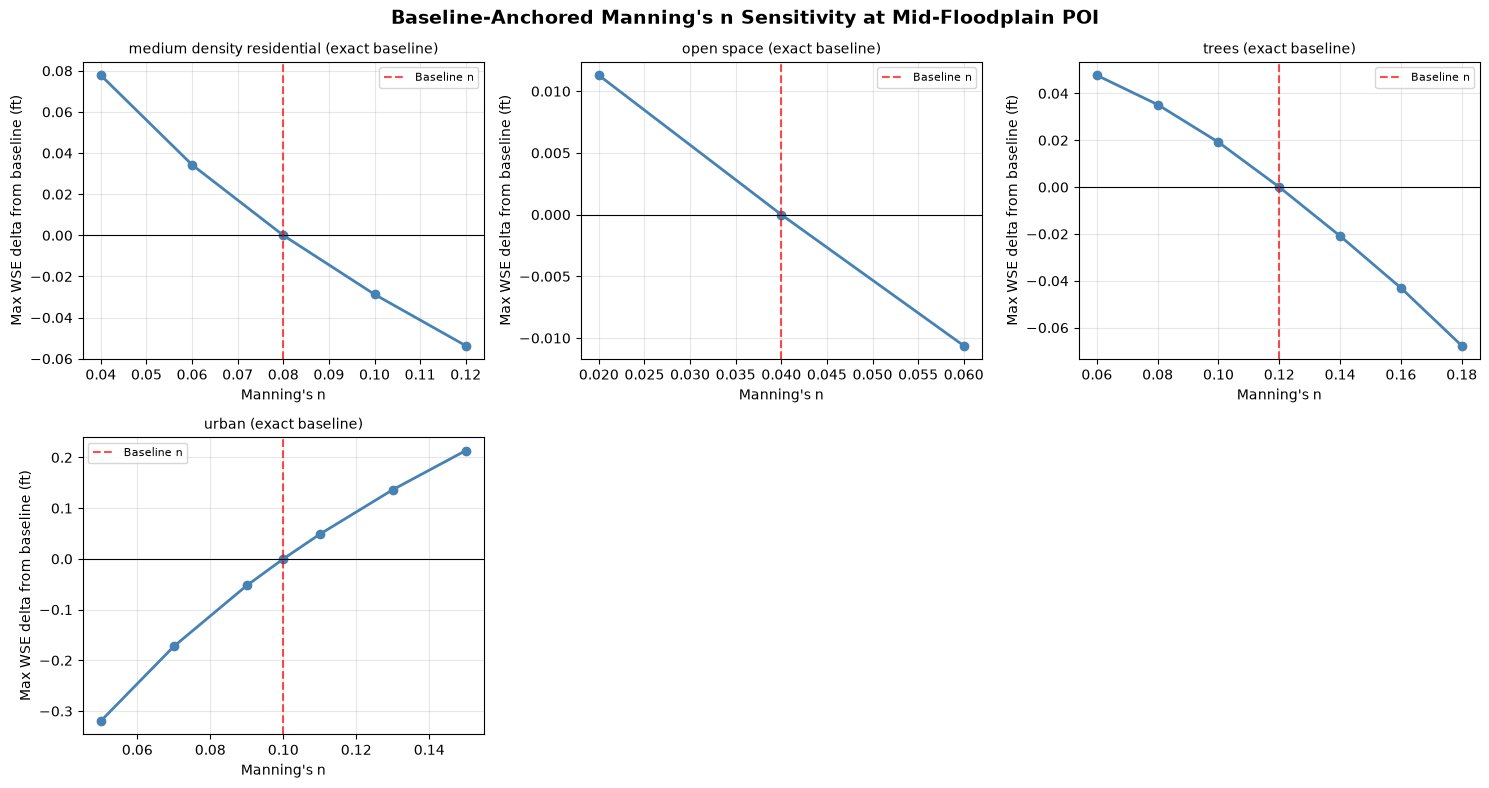

In [13]:
land_covers = poi_comparison_df["land_cover"].unique()
n_lc = len(land_covers)
ncols = min(3, n_lc)
nrows = int(np.ceil(n_lc / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
fig.suptitle(f"Baseline-Anchored Manning's n Sensitivity at {POI_LABEL}", fontsize=14, fontweight="bold")

for i, lc_name in enumerate(land_covers):
    ax = axes[i // ncols, i % ncols]
    lc_data = poi_comparison_df[poi_comparison_df["land_cover"] == lc_name].sort_values("n_value")
    ref = reference_df[reference_df["land_cover"] == lc_name].iloc[0]
    
    ax.plot(lc_data["n_value"], lc_data["max_wse_delta_ft"], "o-", color="steelblue", linewidth=2)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.axvline(ref["baseline_n"], color="red", linestyle="--", alpha=0.7, label="Baseline n")
    
    ax.set_title(f"{lc_name} ({ref['reference_type'].replace('_', ' ')})", fontsize=10)
    ax.set_xlabel("Manning's n")
    ax.set_ylabel("Max WSE delta from baseline (ft)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(n_lc, nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

plt.tight_layout()
plt.show()


## Tornado Diagram

The tornado diagram ranks land cover classes by their influence on WSE.
Wider bars indicate greater sensitivity — these are the parameters that
matter most for model calibration.

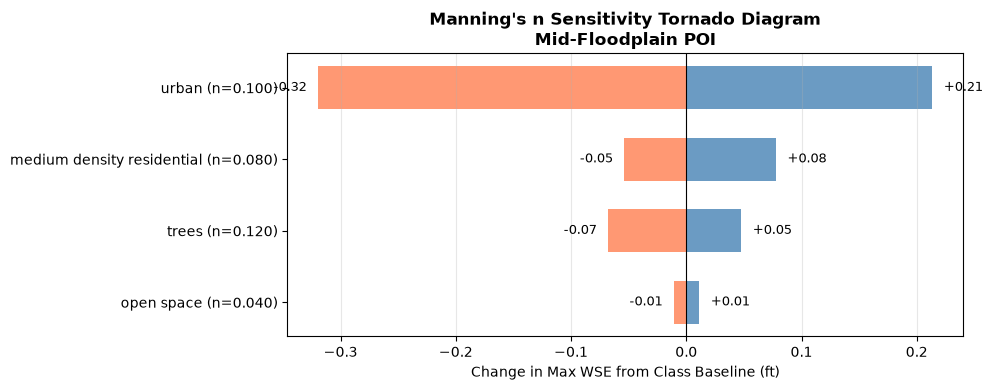


=== Sensitivity Ranking (most to least influential) ===
  urban: WSE delta range = 0.533 ft (n: 0.050 to 0.150)
  medium density residential: WSE delta range = 0.131 ft (n: 0.040 to 0.120)
  trees: WSE delta range = 0.115 ft (n: 0.060 to 0.180)
  open space: WSE delta range = 0.022 ft (n: 0.020 to 0.060)


In [14]:
# Calculate WSE delta range for each land cover.
tornado_data = []
for lc_name, lc_data in poi_comparison_df.groupby("land_cover"):
    lc_data = lc_data.sort_values("n_value")
    ref = reference_df[reference_df["land_cover"] == lc_name].iloc[0]
    
    tornado_data.append({
        "land_cover": lc_name,
        "delta_min_ft": lc_data["max_wse_delta_ft"].min(),
        "delta_max_ft": lc_data["max_wse_delta_ft"].max(),
        "delta_range_ft": lc_data["max_wse_delta_ft"].max() - lc_data["max_wse_delta_ft"].min(),
        "baseline_n": ref["baseline_n"],
        "reference_wse_ft": ref["reference_wse_ft"],
        "reference_type": ref["reference_type"],
        "n_min": lc_data["n_value"].min(),
        "n_max": lc_data["n_value"].max(),
    })

tornado_df = pd.DataFrame(tornado_data).sort_values("delta_range_ft", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(tornado_df) * 0.8)))
y_pos = range(len(tornado_df))

for i, (_, row) in enumerate(tornado_df.iterrows()):
    left = row["delta_min_ft"]
    right = row["delta_max_ft"]
    
    ax.barh(i, right, left=0, height=0.6, color="steelblue", alpha=0.8)
    ax.barh(i, left, left=0, height=0.6, color="coral", alpha=0.8)
    
    ax.text(right + 0.01, i, f"+{right:.2f}", va="center", fontsize=9)
    ax.text(left - 0.01, i, f"{left:.2f}", va="center", ha="right", fontsize=9)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f'{r["land_cover"]} (n={r["baseline_n"]:.3f})' for _, r in tornado_df.iterrows()])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in Max WSE from Class Baseline (ft)")
ax.set_title(f"Manning's n Sensitivity Tornado Diagram\n{POI_LABEL}", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Sensitivity Ranking (most to least influential) ===")
for _, row in tornado_df.iloc[::-1].iterrows():
    print(f'  {row["land_cover"]}: WSE delta range = {row["delta_range_ft"]:.3f} ft '
          f'(n: {row["n_min"]:.3f} to {row["n_max"]:.3f})')


## Export Results

Save the full results table and tornado summary as CSV files for
further analysis or reporting.

In [15]:
output_dir = Path.cwd() / "working" / "711_mannings_sensitivity"
output_dir.mkdir(parents=True, exist_ok=True)


def _display_output_path(path):
    try:
        return path.relative_to(Path.cwd())
    except ValueError:
        return path.name

# Full POI results table
results_csv = output_dir / "oat_sensitivity_results.csv"
results_df.to_csv(results_csv, index=False)
print(f"Full results: {_display_output_path(results_csv)}")

# Baseline-anchored POI deltas
comparison_csv = output_dir / "oat_sensitivity_poi_deltas.csv"
poi_comparison_df.to_csv(comparison_csv, index=False)
print(f"POI deltas: {_display_output_path(comparison_csv)}")

# Tornado summary
tornado_csv = output_dir / "oat_sensitivity_tornado.csv"
tornado_df.to_csv(tornado_csv, index=False)
print(f"Tornado summary: {_display_output_path(tornado_csv)}")

if not inactive_propagation_df.empty:
    propagation_csv = output_dir / "oat_sensitivity_propagation_qaqc.csv"
    propagation_df.to_csv(propagation_csv, index=False)
    print(f"Propagation QA: {_display_output_path(propagation_csv)}")

print(f"\nTotal active plans analyzed: {len(results_df)}")
print(f"Land covers varied in hydraulic plots: {results_df['land_cover'].nunique()}")
print(f"Overall WSE range: {results_df['max_wse_ft'].max() - results_df['max_wse_ft'].min():.3f} ft")
print(f"Overall baseline-anchored delta range: {poi_comparison_df['max_wse_delta_ft'].max() - poi_comparison_df['max_wse_delta_ft'].min():.3f} ft")


Full results: working\711_mannings_sensitivity\oat_sensitivity_results.csv
POI deltas: working\711_mannings_sensitivity\oat_sensitivity_poi_deltas.csv
Tornado summary: working\711_mannings_sensitivity\oat_sensitivity_tornado.csv
Propagation QA: working\711_mannings_sensitivity\oat_sensitivity_propagation_qaqc.csv

Total active plans analyzed: 22
Land covers varied in hydraulic plots: 4
Overall WSE range: 0.533 ft
Overall baseline-anchored delta range: 0.533 ft


## Cleanup

Remove the extracted example project to free disk space.

In [16]:
import shutil

example_projects_dir = project_folder.parent
if example_projects_dir.name == "example_projects" and example_projects_dir.exists():
    shutil.rmtree(example_projects_dir, ignore_errors=True)
    print("Cleaned up: example_projects")
else:
    print("Skipping cleanup: example_projects")

Cleaned up: example_projects
